In [6]:
import numpy as np
from dipy.io.streamline import load_tractogram,save_tractogram
from dipy.io.utils import Space
from sklearn.cluster import KMeans

import sys
sys.path.append('../script/')
from from_trx_to_numpy import trx_to_numpy_tract_array
from build_cores_MAS import average_MAS_per_labels,infer_labels_svm_endpoint

# forall subject forall tract
dataset='PPMI/PD/'
subject='100268'
TRACT='CST_right'
n_clusters=10

path='/home/gui/Documents/Post-doc/data/'+dataset
MAS_path=path+subject+'/06-AugmentedTractsOT/6augmented_'+TRACT+'_n40_c30.trx'
svm_path=path+'/000000/05-Tracts/svm/svm_'+str(TRACT)+'.pkl'
output_path=path+subject+'/06-AugmentedTractsOT/7cores_MAS_'+TRACT+'_L'+str(n_clusters)+'.trx'

MAS = load_tractogram(
    MAS_path, reference='same',to_space=Space.LPSMM)

nb_pts=40
nb_streamline=len(MAS.streamlines)

m,wI,I,w,S,conf,_=trx_to_numpy_tract_array(MAS,nb_streamline)
print(m.shape,wI.shape,I.shape,w.shape,S.shape,conf.shape)

labels_svm,labels_clus=infer_labels_svm_endpoint(svm_path,n_clusters,m,random_state=0)
print(labels_svm.shape,labels_clus.shape)

(941, 40, 3) (941, 40) (941, 40) (941, 40, 4) (941, 40, 4, 3, 3) (941, 40)


/home/gui/Documents/Post-doc/code/TractOT/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


(941, 40) (941,)


In [7]:
labels_svm.min(),labels_clus

(np.int64(8),
 array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 6, 4, 4, 4, 4, 6, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 8, 9, 2, 2, 2,
        2, 8, 9, 2, 2, 2, 2, 8, 8, 9, 9, 4, 4, 4, 6, 8, 9, 9, 4, 4, 4, 6,
        6, 6, 9, 4, 4, 4, 4, 6, 6, 9, 4, 4, 4, 4, 6, 4, 4, 4, 6, 4, 4, 2,
        2, 2, 2, 8, 8, 2, 2, 2, 2, 8, 8, 9, 2, 8, 8, 8, 9, 9, 8, 8, 8, 9,
        9, 6, 8, 8, 0, 9, 4, 6, 6, 6, 0, 4, 4, 6, 6, 6, 4, 4, 6, 6, 6, 6,
        6, 6, 6, 6, 6, 6, 4, 2, 2, 2, 2, 8, 9, 2, 2, 8, 8, 0, 9, 9, 9, 8,
        8, 0, 0, 9, 9, 9, 8, 8, 0, 0, 9, 9, 6, 8, 0, 9, 6, 6, 6, 6, 9, 6,
        6, 6, 6, 6, 6, 6, 6, 6, 8, 2, 8, 2, 0, 0, 9, 9, 9, 2, 0, 0, 9, 9,
        9, 8, 0, 0, 9, 9, 8, 8, 0, 9, 6, 9, 6, 6, 6, 6, 6, 6, 6, 6, 6, 0,
        9, 9, 0, 9, 9, 9, 2, 8, 8, 0, 8, 8, 8, 8, 6, 6, 6, 6, 6, 6, 6, 6,
        8, 8, 9, 9, 9, 6, 8, 8, 8, 0, 6, 6, 8, 6, 6, 6, 6, 6, 8, 8, 6, 8,
        8, 0, 0, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 8, 6, 8, 8, 8, 8, 8, 6, 6,
        6, 6, 6, 6, 6, 6

In [8]:


cores_m,cores_wI,cores_I,cores_w,cores_S,idx_svm,idx_cluster,size_cluster=average_MAS_per_labels(n_clusters,m,wI,I,w,S,conf,labels_svm,labels_clus)

print(len(cores_m),len(cores_wI),len(cores_I),len(cores_w),len(cores_S),len(idx_svm),len(idx_cluster),len(size_cluster))
print(cores_m[0].shape,cores_wI[0].shape,cores_I[0].shape,cores_w[0].shape,cores_S[0].shape,idx_svm[0].shape,idx_cluster[0].shape,size_cluster[0].shape)

cores=MAS.from_sft(cores_m,MAS)
dico={}
dico['weight iso']=cores_wI
dico['iso']=cores_I
dico['weights aniso']=cores_w
dico['aniso']=cores_S
dico['svm']=idx_svm
dico['cluster']=idx_cluster
dico['size cluster']=size_cluster
cores.data_per_point=dico
#save_tractogram(cores,output_path)

l =  0
14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  1
11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  2
12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  3
8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  4
14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  5
9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  6
11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  7
10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  8
9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  9
12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
10 10 10 10 10 10 10 10


In [9]:
size_cluster[0].shape

(27,)

In [10]:
from load_save_vtk import load_vtk_streamlines,save_vtk
output_path_vtk=output_path[:-4]+'.vtk'
save_vtk(cores_m, output_path_vtk,scalar_dict=dico)

In [ ]:
import matplotlib.pylab as pl

# Print cores
r=9
s=1e2
axis=(0,2)
pl.figure(figsize=(75,40))
pl.subplot(1,2,1)
for i in range(n_clusters):
    color1='C%i'%i
    if i<=r:
        pl.scatter(cores_m[i][:,axis[0]], cores_m[i][:,axis[1]],color=color1,s=s)
xmin,ymin,sq=-70,-70,160
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
#pl.axis('off')

pl.subplot(1,2,2)
for i in range(n_clusters):
    #color1='C%i'%i
    #m_i=m[labels_clus==i]
    if i<=r:
        for j,idx in enumerate(np.unique(labels_svm[labels_clus==i])):
            color1='C%i'%(idx-1)
            m_i=m[labels_clus==i][labels_svm[labels_clus==i]==idx]
            pl.scatter(m_i[:,axis[0]], m_i[:,axis[1]],color=color1,s=s)
        #pl.scatter(m_i[:,:,axis[0]], m_i[:,:,axis[1]],color=color1,s=s)
        #pl.scatter(cores_m[i][:,axis[0]], cores_m[i][:,axis[1]],color='red',s=5*s)
xmin,ymin,sq=-70,-70,160
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
#pl.axis('off')
#pl.savefig("/home/gui/Documents/Post-doc/Slides/Pastrami2025/figures/svm.png",bbox_inches='tight')

NameError: name 'labels_svm' is not defined

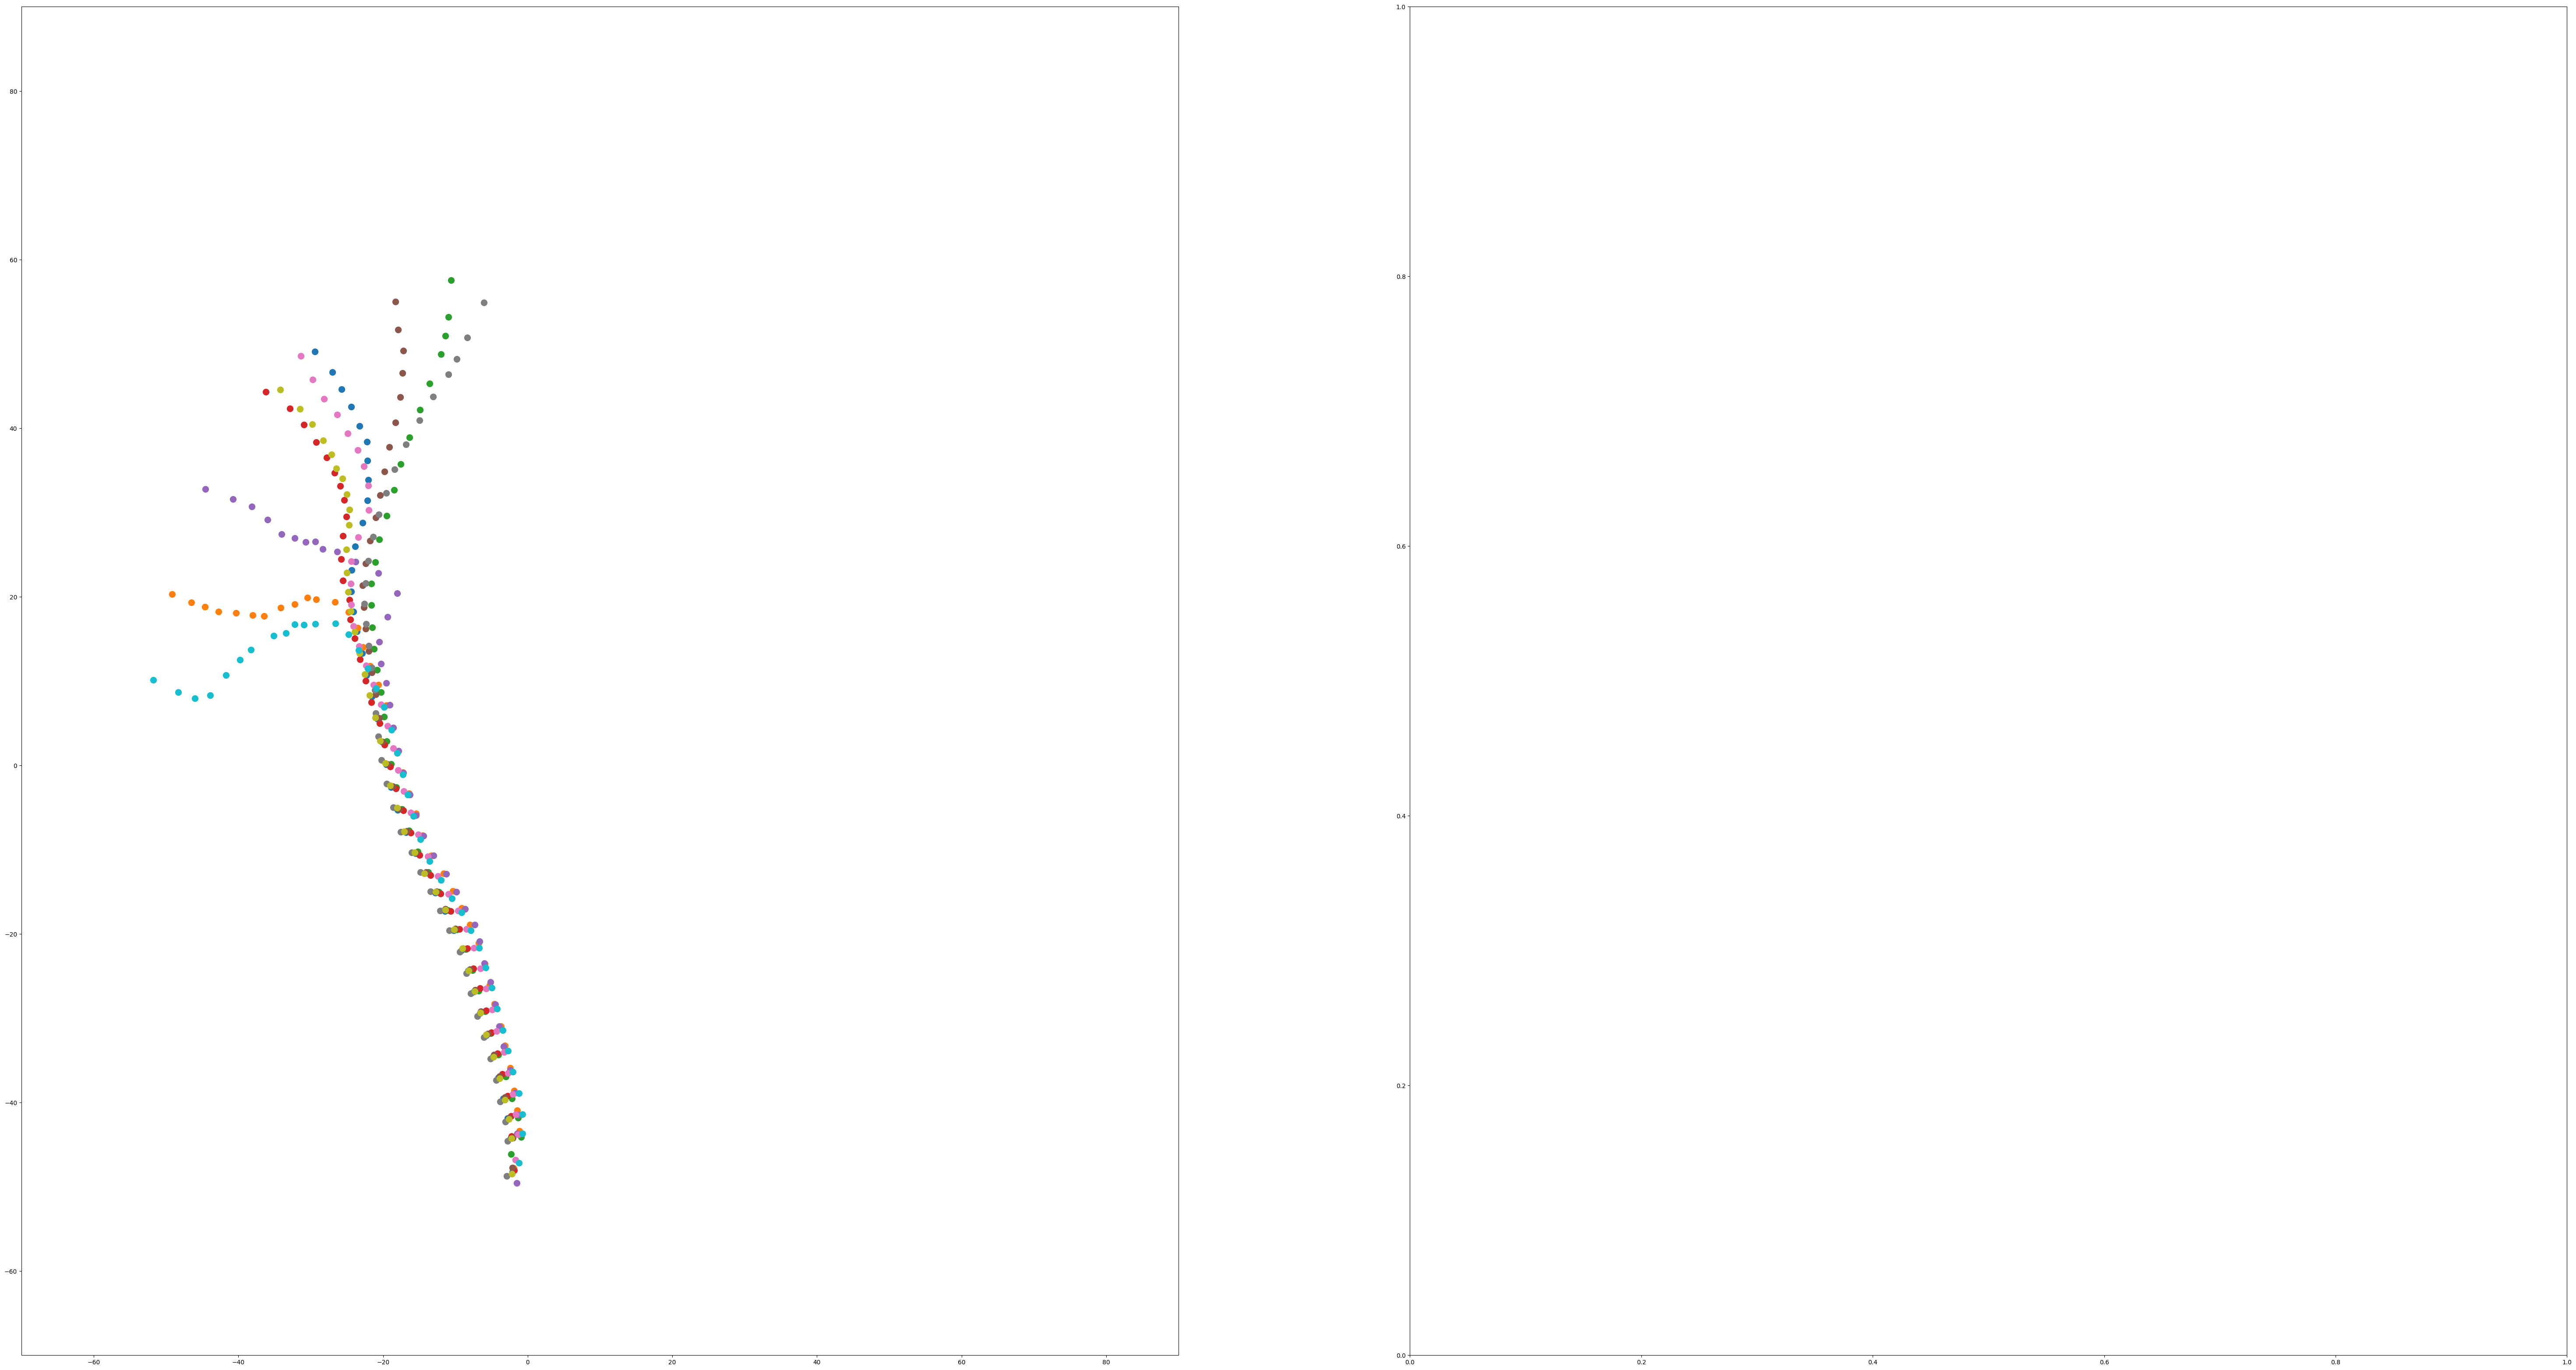

In [5]:
import matplotlib.pylab as pl

# Print cores
r=9
s=1e2
axis=(0,2)
pl.figure(figsize=(75,40))
pl.subplot(1,2,1)
for i in range(n_clusters):
    color1='C%i'%i
    if i<=r:
        pl.scatter(cores_m[i][:,axis[0]], cores_m[i][:,axis[1]],color=color1,s=s)
xmin,ymin,sq=-70,-70,160
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
#pl.axis('off')

pl.subplot(1,2,2)
for i in range(n_clusters):
    #color1='C%i'%i
    #m_i=m[labels_clus==i]
    if i<=r:
        for j,idx in enumerate(np.unique(labels_svm[labels_clus==i])):
            color1='C%i'%(idx-1)
            m_i=m[labels_clus==i][labels_svm[labels_clus==i]==idx]
            pl.scatter(m_i[:,axis[0]], m_i[:,axis[1]],color=color1,s=s)
        #pl.scatter(m_i[:,:,axis[0]], m_i[:,:,axis[1]],color=color1,s=s)
        #pl.scatter(cores_m[i][:,axis[0]], cores_m[i][:,axis[1]],color='red',s=5*s)
xmin,ymin,sq=-70,-70,160
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
#pl.axis('off')
#pl.savefig("/home/gui/Documents/Post-doc/Slides/Pastrami2025/figures/svm.png",bbox_inches='tight')

In [2]:
#Convert to .vtk

import numpy as np
from dipy.io.streamline import load_tractogram
import sys
sys.path.append('../script/')
from load_save_vtk import load_vtk_streamlines,save_vtk

path='/home/gui/Documents/Post-doc/data/HCP_105/000000'

TRACT='CST_right'
n_clusters=10

SUBJECTS=['599469', '599671', '601127', '613538', '620434', '622236', '623844', '627549', '638049', '644044', '645551',
          '654754', '665254','672756','673455', '677968', '679568', '680957', '683256', '685058', '687163', '690152',
          '695768', '702133', '704238', '705341', '709551','715041','715647','729254', '729557', '732243', '734045',
          '742549','748258', '748662', '749361', '751348', '753251','756055','759869', '761957','765056', '770352','771354', '779370',
          '782561', '784565', '786569', '789373', '792564', '792766', '802844', '814649', '816653', '826353','826454', '833148',
          '833249','837560', '837964', '845458', '849971', '856766', '857263', '859671', '861456', '865363', '871762', '871964',
          '872158', '872764', '877168', '877269','887373', '889579', '894673', '896778', '896879', '898176', '899885', '901038',
          '901139', '901442','904044', '907656', '910241', '912447', '917255','922854', '930449', '932554', '951457', '957974',
          '958976', '959574', '965367', '965771','978578', '979984', '983773', '984472', '987983', '991267','992774']


for subject in SUBJECTS:
    input_path=path+'/06-AugmentedTractsOT/'+subject+'_7cores_MAS_'+TRACT+'_L'+str(n_clusters)+'.trx'
    
    cores = load_tractogram(
        input_path, reference='same')
    
    
    output_path_vtk=input_path[:-4]+'.vtk'
    cores_m=cores.streamlines
    
    dico={}
    dico['weight iso']=list(cores.data_per_point['weight iso'])
    dico['iso']=list(cores.data_per_point['iso'])
    dico['weights aniso']=list(cores.data_per_point['weights aniso'])
    dico['aniso']=list(cores.data_per_point['aniso'])
    dico['svm']=list(cores.data_per_point['svm'])
    dico['cluster']=list(cores.data_per_point['cluster'])
    dico['size cluster']=list(cores.data_per_point['size cluster'])
    save_vtk(cores_m, output_path_vtk,scalar_dict=dico)

In [5]:
streamlines = load_tractogram(
        '/home/gui/Bureau/CST_right.tck', reference='/home/gui/Bureau/ref.nii.gz')

In [6]:
len(streamlines.streamlines)

2000

In [9]:
from dipy.io.streamline import save_tractogram
save_tractogram(streamlines,'/home/gui/Bureau/CST_right.vtk')

/home/gui/Documents/Post-doc/code/TractOT/.venv/lib/python3.12/site-packages/fury/colormap.py:234: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  orient = np.abs(np.divide(v, r, where=r != 0))


True